# 03 — Spot Price Fundamentals

**Evaluation: Insight** — What fundamental factors influence the spot price the most?

Spot price is set by marginal pricing: the cost of the last unit needed to meet demand. We explore load, renewable share, and cross-border flows as drivers.

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import matplotlib.pyplot as plt
from src.data_loader import load_spot_price, load_total_load, load_generation_pivot, load_flows_into

## Load vs price (Germany)

Correlation: load vs price = 0.307


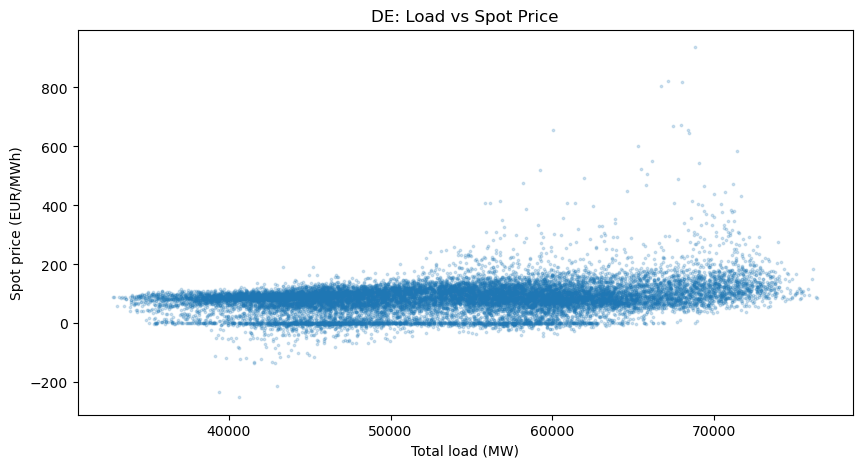

In [2]:
sp = load_spot_price("DE")
load = load_total_load("DE")
load_h = load.resample("1h").mean()
join = sp.join(load_h, how="inner")

corr_load = join["load"].corr(join["price"])
print(f"Correlation: load vs price = {corr_load:.3f}")

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(join["load"], join["price"], alpha=0.2, s=3)
ax.set_xlabel("Total load (MW)")
ax.set_ylabel("Spot price (EUR/MWh)")
ax.set_title("DE: Load vs Spot Price")
plt.show()

## Renewable share vs price

Correlation: renewable_share vs price = -0.748
Interpretation: Higher renewable share → lower marginal cost → lower price.


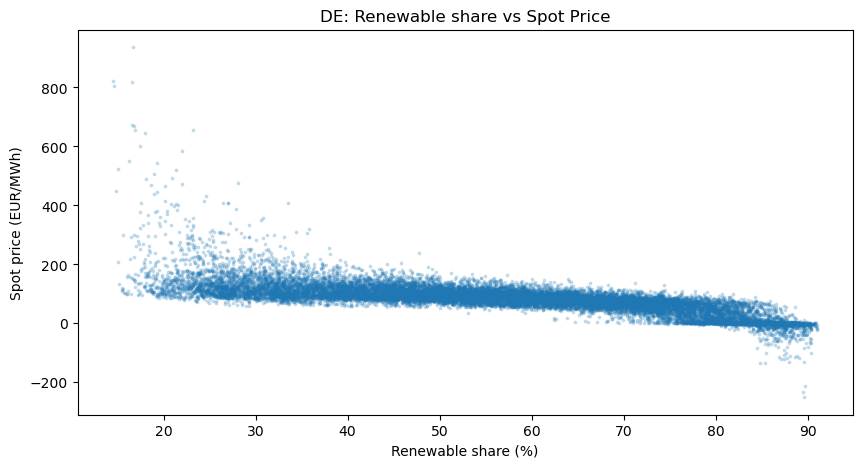

In [3]:
gen = load_generation_pivot("DE")
renewables = ["SOLAR", "WIND-ONSHORE", "WIND-OFFSHORE", "HYDRO-ROR", "HYDRO-WATER-RESERVOIR", "BIOMASS", "OTHER-RENEWABLE"]
ren_cols = [c for c in renewables if c in gen.columns]
gen["renewable"] = gen[ren_cols].sum(axis=1)
gen["total"] = gen[[c for c in gen.columns if c not in ["renewable", "total"]]].sum(axis=1)
gen["renewable_share"] = gen["renewable"] / gen["total"].replace(0, pd.NA)

gen_h = gen[["renewable_share"]].resample("1h").mean()
join2 = sp.join(gen_h, how="inner").dropna()

corr_ren = join2["renewable_share"].corr(join2["price"])
print(f"Correlation: renewable_share vs price = {corr_ren:.3f}")
print("Interpretation: Higher renewable share → lower marginal cost → lower price.")

plt.figure(figsize=(10, 5))
plt.scatter(join2["renewable_share"] * 100, join2["price"], alpha=0.2, s=3)
plt.xlabel("Renewable share (%)")
plt.ylabel("Spot price (EUR/MWh)")
plt.title("DE: Renewable share vs Spot Price")
plt.show()

## Price distribution by hour of day

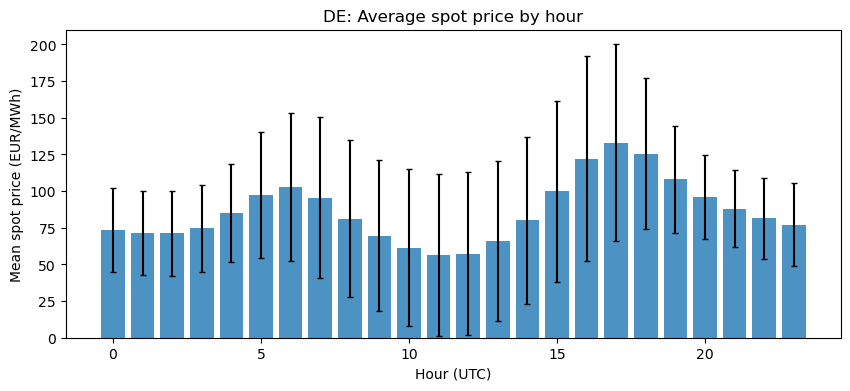

In [4]:
sp["hour"] = sp.index.hour
sp["month"] = sp.index.month

by_hour = sp.groupby("hour")["price"].agg(["mean", "std", "median"])
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(by_hour.index, by_hour["mean"], yerr=by_hour["std"], capsize=2, alpha=0.8)
ax.set_xlabel("Hour (UTC)")
ax.set_ylabel("Mean spot price (EUR/MWh)")
ax.set_title("DE: Average spot price by hour")
plt.show()

## Cross-zone price comparison

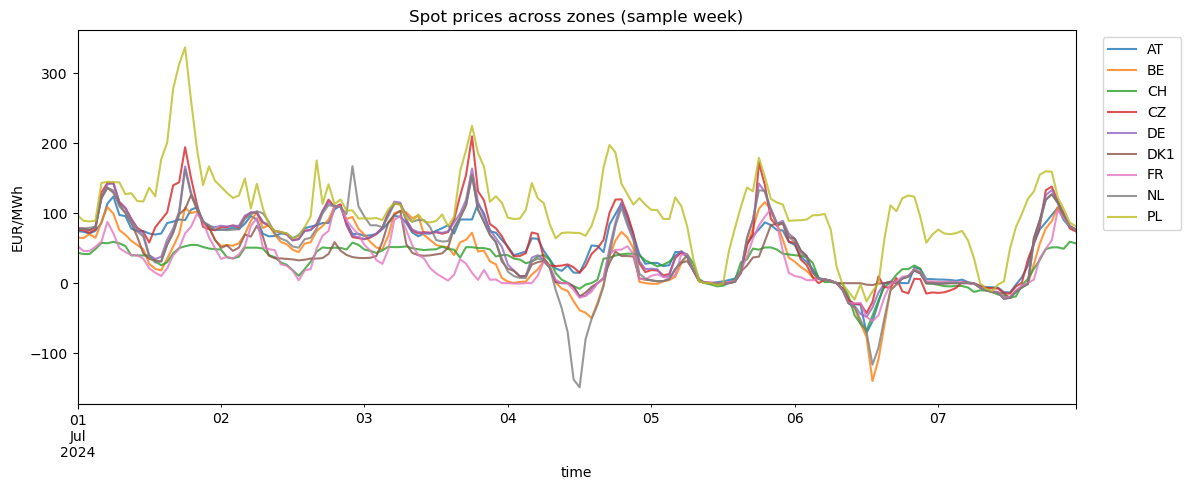

In [5]:
from src.data_loader import load_all_spot_prices

all_sp = load_all_spot_prices()
all_sp.columns = all_sp.columns.get_level_values(0)  # flatten if multiindex

sample = all_sp.loc["2024-07-01":"2024-07-07"]
sample.plot(figsize=(12, 5), alpha=0.8)
plt.ylabel("EUR/MWh")
plt.title("Spot prices across zones (sample week)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()